In [5]:
install.packages(c("sqldf", "dplyr", "ggplot2", "scales", "corrplot"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [6]:
library(sqldf)
library(dplyr)
library(ggplot2)
library(scales)
library(corrplot)

cat("Libraries loaded.\n")

Libraries loaded.


In [7]:
customers  <- read.csv("customers.csv",  stringsAsFactors=FALSE)
orders     <- read.csv("orders.csv",     stringsAsFactors=FALSE)
deliveries <- read.csv("deliveries.csv", stringsAsFactors=FALSE)
drivers    <- read.csv("drivers.csv",    stringsAsFactors=FALSE)
vehicles   <- read.csv("vehicles.csv",   stringsAsFactors=FALSE)
hubs       <- read.csv("hubs.csv",       stringsAsFactors=FALSE)
incidents  <- read.csv("incidents.csv",  stringsAsFactors=FALSE)
complaints <- read.csv("complaints.csv", stringsAsFactors=FALSE)
app_events <- read.csv("app_events.csv", stringsAsFactors=FALSE)

cat("Files loaded.\n")
cat("Deliveries rows:", nrow(deliveries), "\n")
cat("Orders rows:",     nrow(orders), "\n")

Files loaded.
Deliveries rows: 950 
Orders rows: 1250 


In [8]:

standardise_zone <- function(x) {
  raw   <- c("AIRPORT","Airport","NORTH","North","north","SOUTH","South",
             "EAST","East","WEST","West","CENTRAL","Central","Ctr",
             "RiverSide","Riverside")
  clean <- c("Airport","Airport","North","North","North","South","South",
             "East","East","West","West","Central","Central","Central",
             "Riverside","Riverside")
  idx <- match(x, raw)
  ifelse(is.na(idx), x, clean[idx])
}

customers$home_zone      <- standardise_zone(customers$home_zone)
orders$pickup_zone       <- standardise_zone(orders$pickup_zone)
orders$dropoff_zone      <- standardise_zone(orders$dropoff_zone)
drivers$base_zone        <- standardise_zone(drivers$base_zone)
vehicles$assigned_zone   <- standardise_zone(vehicles$assigned_zone)
app_events$zone_context  <- standardise_zone(app_events$zone_context)

cat("Zone standardisation complete.\n")
cat("Unique zones:", paste(sort(unique(orders$pickup_zone)), collapse=", "), "\n")

Zone standardisation complete.
Unique zones: Airport, Central, East, North, Riverside, South, West 


In [9]:
deliveries$customer_rating_post_delivery[is.na(deliveries$customer_rating_post_delivery)] <-
  median(deliveries$customer_rating_post_delivery, na.rm=TRUE)
drivers$training_score[is.na(drivers$training_score)] <-
  median(drivers$training_score, na.rm=TRUE)
vehicles$battery_health_pct[is.na(vehicles$battery_health_pct)] <-
  median(vehicles$battery_health_pct, na.rm=TRUE)
customers$loyalty_score[is.na(customers$loyalty_score)] <-
  median(customers$loyalty_score, na.rm=TRUE)

cat("Missing values imputed.\n")

Missing values imputed.


In [10]:
deliveries$is_failed  <- as.integer(deliveries$delivery_status == "Failed")
deliveries$is_delayed <- as.integer(deliveries$delivery_status == "Delayed")

cat("Outcome flags created.\n")

Outcome flags created.


In [11]:
result <- sqldf("
SELECT
    o.pickup_zone                                              AS zone,
    COUNT(d.delivery_id)                                       AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          / COUNT(d.delivery_id), 2)                           AS failure_rate_pct,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                       AS avg_fuel_cost,
    ROUND(AVG(d.customer_rating_post_delivery), 2)             AS avg_rating,
    ROUND(AVG(d.manual_route_override_count), 2)               AS avg_overrides
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE o.pickup_zone IS NOT NULL
GROUP BY o.pickup_zone
ORDER BY failure_rate_pct DESC
")
print(result)

       zone total_deliveries failed delayed failure_rate_pct avg_fuel_cost
1   Central              174     33      51            18.97         12.12
2     North              135     22      21            16.30         12.07
3 Riverside              119     18      25            15.13         12.39
4      West              114     14      21            12.28         11.94
5      East              156     19      31            12.18         12.57
6   Airport              113     12      31            10.62         17.08
7     South              139     14      22            10.07         12.48
  avg_rating avg_overrides
1       3.56          1.29
2       3.90          0.70
3       3.87          0.73
4       3.90          0.81
5       3.91          0.79
6       3.99          1.81
7       4.05          0.69


### SQL Query 2 — Drivers with highest failure rates (min 5 deliveries)

In [12]:
result2 <- sqldf("
SELECT
    d.driver_id,
    dr.base_zone,
    dr.employment_type,
    ROUND(dr.training_score, 1)                                AS training_score,
    ROUND(dr.driver_rating, 2)                                 AS driver_rating,
    COUNT(d.delivery_id)                                       AS deliveries,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          / COUNT(d.delivery_id), 1)                           AS failure_rate_pct,
    ROUND(AVG(d.manual_route_override_count), 2)               AS avg_overrides
FROM deliveries d
JOIN drivers dr ON d.driver_id = dr.driver_id
GROUP BY d.driver_id, dr.base_zone, dr.employment_type, dr.training_score, dr.driver_rating
HAVING COUNT(d.delivery_id) >= 5
ORDER BY failure_rate_pct DESC
LIMIT 15
")
print(result2)

   driver_id base_zone employment_type training_score driver_rating deliveries
1       D092      East        FullTime           88.2          4.24          5
2       D104      West        FullTime           87.7          3.45          7
3       D024 Riverside        PartTime           71.4          3.35          8
4       D010      West        FullTime           70.0          3.95          7
5       D005     North        FullTime           69.7          4.14          5
6       D095      West        FullTime           99.0          3.15          5
7       D143   Central        FullTime           68.5          4.14          5
8       D144      West        FullTime           85.0          3.83          5
9       D004   Airport        PartTime           88.9          4.75          9
10      D023      East        FullTime           79.1          4.16          6
11      D078     North        FullTime           73.7          4.28          6
12      D082      West        PartTime           74.

In [13]:
result3 <- sqldf("
SELECT
    c.complaint_type,
    d.delivery_status,
    COUNT(*)                              AS complaint_count,
    ROUND(AVG(c.resolution_days), 1)     AS avg_resolution_days,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation
FROM complaints c
LEFT JOIN deliveries d ON c.order_id = d.order_id
WHERE d.delivery_status IS NOT NULL
GROUP BY c.complaint_type, d.delivery_status
ORDER BY complaint_type, delivery_status
")
print(result3)

ghost <- result3[result3$delivery_status == "OnTime", ]
cat("\nComplaints against OnTime deliveries:\n")
print(ghost[order(-ghost$complaint_count), ])

      complaint_type delivery_status complaint_count avg_resolution_days
1           AppIssue         Delayed               7                10.6
2           AppIssue          Failed               5                10.6
3           AppIssue          OnTime              25                 8.6
4            Billing         Delayed               3                 7.0
5            Billing          Failed               2                 7.0
6            Billing          OnTime               7                 7.7
7             Damage         Delayed               1                16.0
8             Damage          Failed               2                11.0
9             Damage          OnTime               8                 9.6
10             Delay         Delayed              19                 6.9
11             Delay          Failed              10                 8.6
12             Delay          OnTime              44                 7.1
13   DriverBehaviour         Delayed               

In [14]:
result4 <- sqldf("
SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    COUNT(DISTINCT d.delivery_id)                              AS total_deliveries,
    COUNT(DISTINCT i.incident_id)                              AS total_incidents,
    ROUND(100.0 * COUNT(DISTINCT i.incident_id)
          / COUNT(DISTINCT d.delivery_id), 1)                  AS incident_rate_pct,
    ROUND(AVG(i.resolved_hours), 1)                            AS avg_resolve_hours,
    ROUND(AVG(d.customer_rating_post_delivery), 2)             AS avg_rating
FROM hubs h
LEFT JOIN deliveries d ON h.hub_id = d.hub_id
LEFT JOIN incidents  i ON d.delivery_id = i.delivery_id
GROUP BY h.hub_id, h.hub_name, h.zone
ORDER BY incident_rate_pct DESC
")
print(result4)

  hub_id       hub_name      zone total_deliveries total_incidents
1    H05   Central Core   Central              115              39
2    H03      East Dock      East              119              38
3    H02     South Link     South              106              33
4    H06    Airport Hub   Airport              104              32
5    H07  Riverside Hub Riverside              115              35
6    H08  Midtown Relay   Central              128              38
7    H04      West Gate      West              127              34
8    H01 North Exchange     North              136              31
  incident_rate_pct avg_resolve_hours avg_rating
1              33.9              12.2       3.68
2              31.9              11.9       3.90
3              31.1              11.7       3.93
4              30.8              11.9       3.89
5              30.4              12.0       3.87
6              29.7              13.2       3.89
7              26.8              10.9       3.91
8    

In [15]:
result5 <- sqldf("
SELECT
    o.service_type,
    o.pickup_zone                                              AS zone,
    COUNT(d.delivery_id)                                       AS deliveries,
    ROUND(AVG(o.order_value), 2)                               AS avg_order_value,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                       AS avg_fuel_cost,
    ROUND(AVG(o.order_value - d.fuel_or_charge_cost), 2)       AS avg_margin,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          / COUNT(d.delivery_id), 1)                           AS failure_rate_pct
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE o.pickup_zone IS NOT NULL
GROUP BY o.service_type, o.pickup_zone
ORDER BY avg_margin ASC
")
print(result5)

   service_type      zone deliveries avg_order_value avg_fuel_cost avg_margin
1      Business      West         12           71.36         13.22      58.15
2        Parcel Riverside         28           71.70         12.10      59.60
3       Medical     North         18           72.24         12.36      59.88
4        Retail      West         22           72.69         11.18      61.52
5       Medical      East         19           75.17         12.92      62.25
6        Retail      East         34           74.72         12.05      62.67
7      Business   Airport         13           83.22         18.78      64.44
8        Parcel     North         27           79.00         12.52      66.48
9     Passenger   Central         47           78.89         12.15      66.74
10       Retail   Central         49           80.20         12.85      67.35
11     Business     South         19           82.07         13.04      69.03
12      Medical      West         17           82.13         11.

In [16]:
sqldf("CREATE INDEX IF NOT EXISTS idx_del_order ON deliveries(order_id)")

sqldf("CREATE INDEX IF NOT EXISTS idx_ord_zone ON orders(pickup_zone)")

sqldf("CREATE INDEX IF NOT EXISTS idx_comp_order ON complaints(order_id)")

sqldf("CREATE INDEX IF NOT EXISTS idx_inc_del ON incidents(delivery_id)")

sqldf("CREATE INDEX IF NOT EXISTS idx_del_driver ON deliveries(driver_id)")

sqldf("CREATE INDEX IF NOT EXISTS idx_del_hub ON deliveries(hub_id)")

cat("All 6 indexes created.\n")
cat("Indexes reduce row scans from full table size to only matching rows.\n")
cat("e.g. idx_ord_zone means the pickup_zone filter scans only indexed rows,\n")
cat("not all 1250 orders records on every query.\n")

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


...

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

All 6 indexes created.
Indexes reduce row scans from full table size to only matching rows.
e.g. idx_ord_zone means the pickup_zone filter scans only indexed rows,
not all 1250 orders records on every query.


In [17]:
master_r <- deliveries %>%
  left_join(orders   %>% select(order_id, pickup_zone, service_type,
                                 promised_window_hours, order_value),
            by="order_id") %>%
  left_join(drivers  %>% select(driver_id, training_score, driver_rating,
                                 years_experience, employment_type, base_zone),
            by="driver_id") %>%
  left_join(vehicles %>% select(vehicle_id, battery_health_pct, maintenance_status),
            by="vehicle_id") %>%
  left_join(hubs     %>% select(hub_id, hub_name, zone),
            by="hub_id") %>%
  filter(!is.na(pickup_zone))

cat("Master dataframe:", nrow(master_r), "rows,", ncol(master_r), "columns\n")

Master dataframe: 950 rows, 28 columns


In [18]:
zone_table <- table(master_r$pickup_zone, master_r$delivery_status)
print(zone_table)

chi_result <- chisq.test(zone_table)
cat("\nChi-square test: Zone vs Delivery Status\n")
cat(sprintf("  Chi-squared : %.3f\n", chi_result$statistic))
cat(sprintf("  df          : %d\n",   chi_result$parameter))
cat(sprintf("  p-value     : %.4f\n", chi_result$p.value))

if (chi_result$p.value < 0.05) {
  cat("  RESULT: Zone significantly predicts delivery outcome (p < 0.05)\n")
}

           
            Delayed Failed OnTime
  Airport        31     12     70
  Central        51     33     90
  East           31     19    106
  North          21     22     92
  Riverside      25     18     76
  South          22     14    103
  West           21     14     79

Chi-square test: Zone vs Delivery Status
  Chi-squared : 26.118
  df          : 12
  p-value     : 0.0103
  RESULT: Zone significantly predicts delivery outcome (p < 0.05)


In [19]:
lm_model <- lm(customer_rating_post_delivery ~
                 training_score +
                 driver_rating +
                 manual_route_override_count +
                 battery_health_pct +
                 is_failed +
                 is_delayed,
               data = master_r)

summary(lm_model)


Call:
lm(formula = customer_rating_post_delivery ~ training_score + 
    driver_rating + manual_route_override_count + battery_health_pct + 
    is_failed + is_delayed, data = master_r)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.38296 -0.42768  0.02908  0.49581  1.93902 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  4.014263   0.311847  12.873   <2e-16 ***
training_score               0.002223   0.001985   1.120    0.263    
driver_rating                0.069514   0.054495   1.276    0.202    
manual_route_override_count -0.017279   0.020484  -0.844    0.399    
battery_health_pct          -0.002266   0.001829  -1.239    0.216    
is_failed                   -1.221311   0.066531 -18.357   <2e-16 ***
is_delayed                  -1.135321   0.056039 -20.259   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6884 on 943 degrees of freedom
Multiple

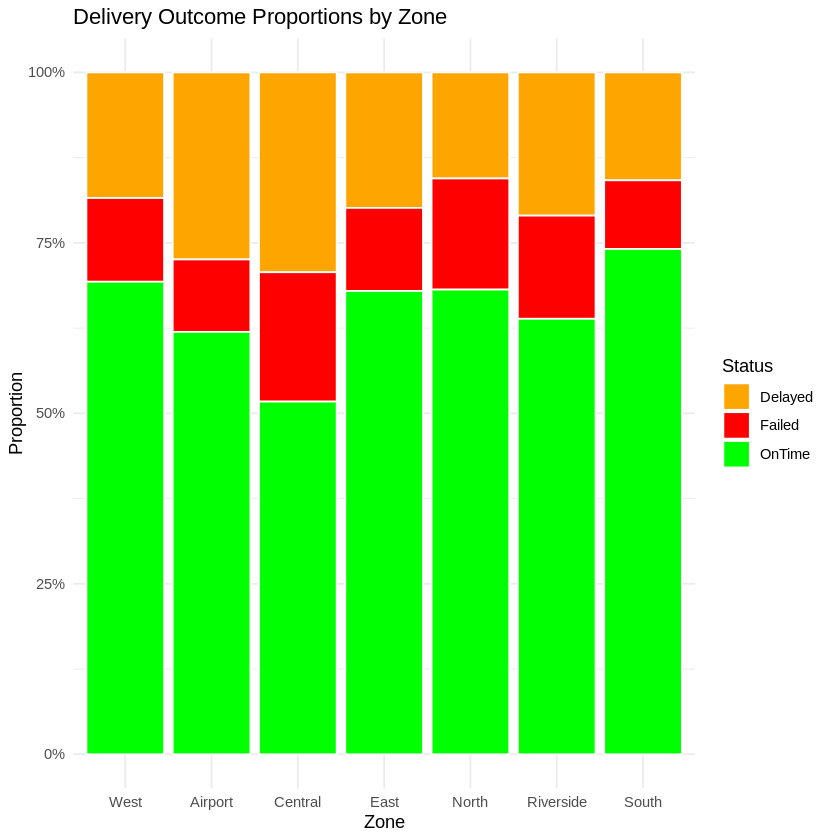

In [20]:
zone_long <- master_r %>%
  count(pickup_zone, delivery_status) %>%
  group_by(pickup_zone) %>%
  mutate(pct = n / sum(n)) %>%
  ungroup()

ggplot(zone_long, aes(x=reorder(pickup_zone, -pct), y=pct, fill=delivery_status)) +
  geom_bar(stat="identity", colour="white") +
  scale_fill_manual(values=c("OnTime"="green","Delayed"="orange","Failed"="red")) +
  scale_y_continuous(labels=percent_format()) +
  labs(title="Delivery Outcome Proportions by Zone",
       x="Zone", y="Proportion", fill="Status") +
  theme_minimal()

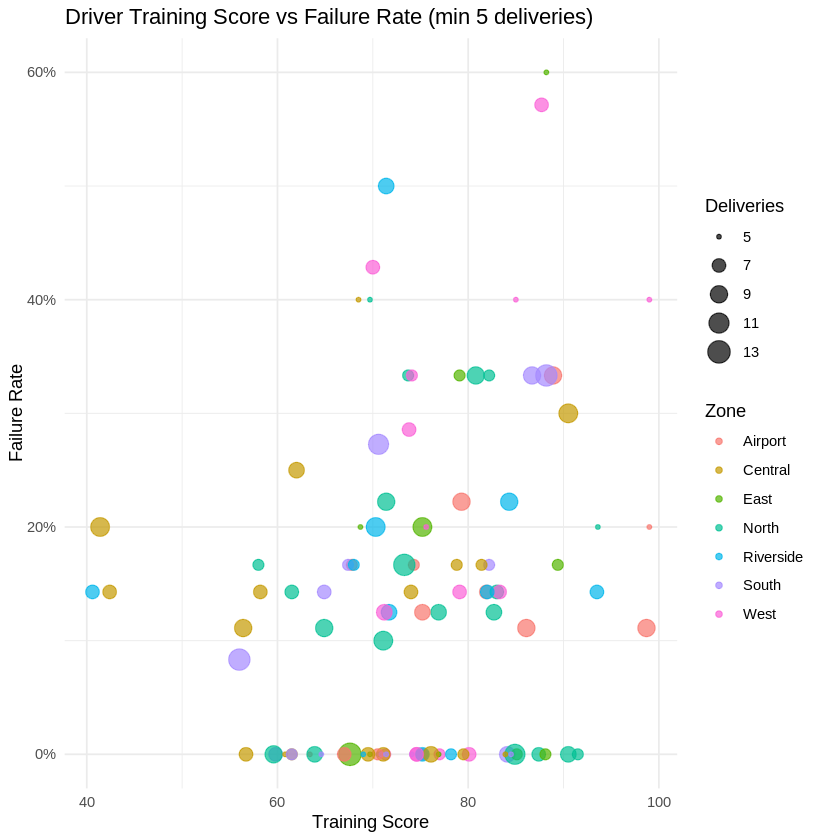

In [21]:
driver_zone <- deliveries %>%
  left_join(drivers %>% select(driver_id, training_score, base_zone), by="driver_id") %>%
  group_by(driver_id, base_zone, training_score) %>%
  summarise(failure_rate=mean(is_failed), n=n(), .groups="drop") %>%
  filter(n >= 5, !is.na(training_score))

ggplot(driver_zone, aes(x=training_score, y=failure_rate, colour=base_zone, size=n)) +
  geom_point(alpha=0.7) +
  scale_y_continuous(labels=percent_format()) +
  labs(title="Driver Training Score vs Failure Rate (min 5 deliveries)",
       x="Training Score", y="Failure Rate",
       colour="Zone", size="Deliveries") +
  theme_minimal()

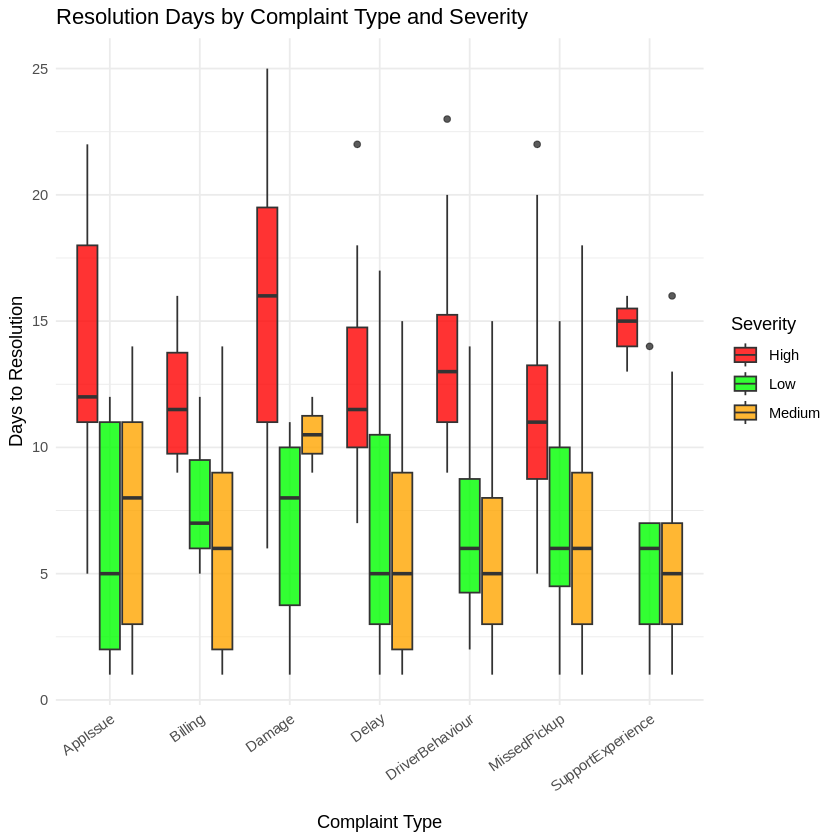

In [22]:
complaints$created_at <- as.POSIXct(complaints$created_at, format="%Y-%m-%d %H:%M:%S")

ggplot(complaints[!is.na(complaints$resolution_days), ],
       aes(x=complaint_type, y=resolution_days, fill=severity)) +
  geom_boxplot(alpha=0.8) +
  scale_fill_manual(values=c("High"="red","Medium"="orange","Low"="green")) +
  labs(title="Resolution Days by Complaint Type and Severity",
       x="Complaint Type", y="Days to Resolution", fill="Severity") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=35, hjust=1))

# A tibble: 2 × 3
  risk_group avg_loyalty count
  <chr>            <dbl> <int>
1 High-Risk         58.1    74
2 Normal            59.9   576


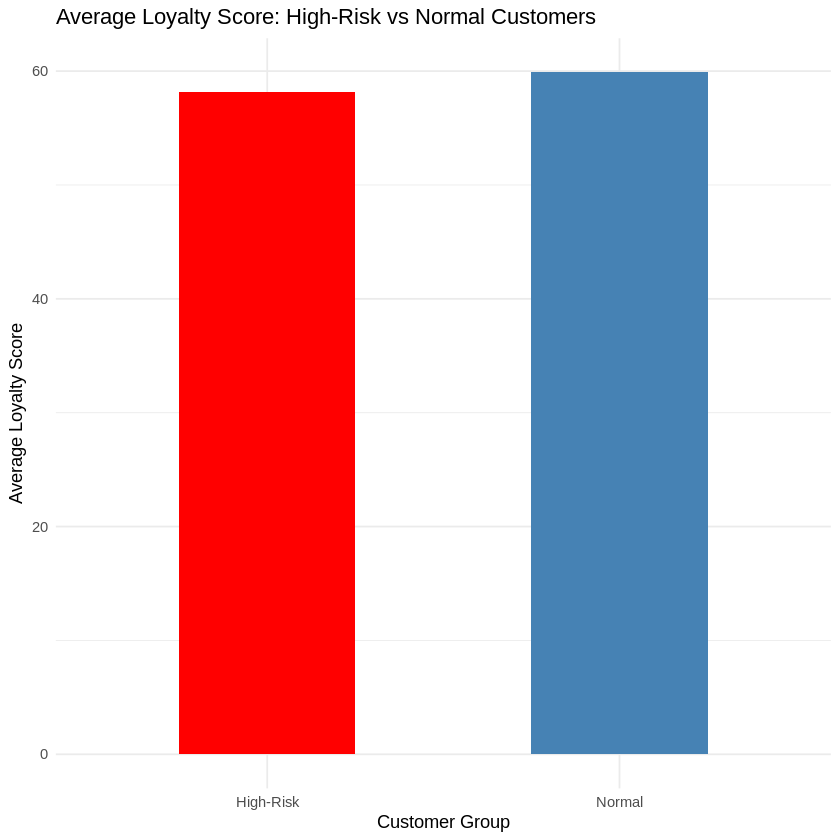

In [23]:
complaint_counts_r <- complaints %>%
  count(customer_id, name="complaint_count")
customers <- customers %>%
  left_join(complaint_counts_r, by="customer_id") %>%
  mutate(complaint_count = ifelse(is.na(complaint_count), 0, complaint_count),
         risk_group = ifelse(complaint_count >= 2, "High-Risk", "Normal"))

avg_loyalty <- customers %>%
  group_by(risk_group) %>%
  summarise(avg_loyalty = mean(loyalty_score, na.rm=TRUE), count=n())

print(avg_loyalty)

ggplot(avg_loyalty, aes(x=risk_group, y=avg_loyalty, fill=risk_group)) +
  geom_bar(stat="identity", width=0.5) +
  scale_fill_manual(values=c("High-Risk"="red","Normal"="steelblue")) +
  labs(title="Average Loyalty Score: High-Risk vs Normal Customers",
       x="Customer Group", y="Average Loyalty Score") +
  theme_minimal() +
  theme(legend.position="none")

In [24]:
cat(paste(rep("=",55), collapse=""), "\n")
cat("KEY FINDINGS\n")
cat(paste(rep("=",55), collapse=""), "\n\n")

zone_summary <- master_r %>%
  group_by(pickup_zone) %>%
  summarise(failure_rate=mean(is_failed), .groups="drop") %>%
  arrange(desc(failure_rate))

cat("1. Failure rates by zone:\n")
for (i in 1:nrow(zone_summary)) {
  cat(sprintf("   %-10s: %.1f%%\n",
    zone_summary$pickup_zone[i], zone_summary$failure_rate[i]*100))
}

cat(sprintf("\n2. Chi-square: zone predicts outcome (p=%.4f)\n", chi_result$p.value))
cat("\n3. Linear model: is_failed and is_delayed are strongest\n")
cat("   negative predictors of customer_rating_post_delivery\n")
cat("\n4. Ghost-completed complaints visible in SQL Query 3\n")

KEY FINDINGS

1. Failure rates by zone:
   Central   : 19.0%
   North     : 16.3%
   Riverside : 15.1%
   West      : 12.3%
   East      : 12.2%
   Airport   : 10.6%
   South     : 10.1%

2. Chi-square: zone predicts outcome (p=0.0103)

3. Linear model: is_failed and is_delayed are strongest
   negative predictors of customer_rating_post_delivery

4. Ghost-completed complaints visible in SQL Query 3
